In [1]:
import os
import numpy as np
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline

# Obtener el path al archivo .db del baseline simulado
baseline_file = get_baseline()
conn = baseline_file  # usar directamente el path como string

outDir = 'temp'
resultsDb = maf.db.ResultsDb()  # <- CORREGIDO

# Coordenadas
Ra, Dec = 270, -30
ra = [Ra]
dec = [Dec]

# Métrica
metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])

# Slicer
slicer = maf.slicers.UserPointsSlicer(ra=ra, dec=dec)

# SQL vacío
sql = ''

# Crear MetricBundle
metric_bundle = maf.MetricBundle(metric, slicer, sql)
bundleDict = {'my_bundle': metric_bundle}

# Ejecutar
bg = maf.MetricBundleGroup(bundleDict, conn, out_dir=outDir, results_db=resultsDb)
bg.run_all()


# Ver resultado
dataSlice = metric_bundle.metric_values[0]
print("Data slice:", dataSlice)


Data slice: [('y', 268.87400589, 62754.12414483,  -8.26996137, 21.69349242, -28.60776889)
 ('y', 268.87400589, 62754.10129085,  -8.26996137, 21.70971516, -28.60776889)
 ('r', 268.66069603, 63041.0234675 , 197.72513443, 23.89843319, -28.55809045)
 ...
 ('g', 271.06264576, 63738.37042616, -19.41459364, 24.07856365, -29.39531689)
 ('g', 272.14197626, 64547.16304929,  10.96006464, 24.40836179, -29.57592946)
 ('r', 272.14197626, 64547.18718397,  10.96006464, 23.60075374, -29.57592946)]


In [7]:
{f: max(dataSlice[dataSlice['filter']==f]['fiveSigmaDepth']) for f in 'ugrizy'}

{'u': np.float64(23.84310878069171),
 'g': np.float64(25.85541372733996),
 'r': np.float64(24.869749376199714),
 'i': np.float64(24.293404515574974),
 'z': np.float64(23.70813344712104),
 'y': np.float64(22.52238790381355)}

In [11]:
{'a':1}|{'b':2}

{'a': 1, 'b': 2}

Text(0.5, 0, 'mag')

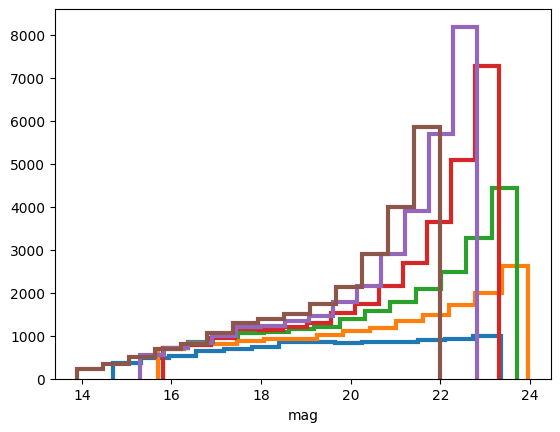

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 
from scipy import stats
dfs = []
for i in range(1,11):
    data_split = pd.read_csv(f'../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{i}.csv')
    dfs.append(data_split)
data = pd.concat(dfs, ignore_index=True)

data['y'] = data['Y']
bands = ['W149','u','g','r','i','z','y']

mag_lim = {f: np.mean(dataSlice[dataSlice['filter']==f]['fiveSigmaDepth']) for f in 'ugrizy'}|{'W149':27.6}
mag_sat = {'W149': 14.8, 'u': 14.7, 'g': 15.7, 'r': 15.8, 'i': 15.8, 'z': 15.3, 'y': 13.9}

for f in bands:
    # if f =='W149':
    #     plt.hist(data[f], bins= np.linspace(mag_sat[f], mag_lim[f], 15),
                 # alpha=0.9,rwidth=0.8,edgecolor='k',linewidth=0.5,color='pink')
    if not f =='W149':
        plt.hist(data[f], bins= np.linspace(mag_sat[f], mag_lim[f], 15),
                 histtype='step',alpha=1,linewidth=3)


# plt.yscale('log')
plt.xlabel("mag")
# plt.xscale('log')